<a href="https://colab.research.google.com/github/rpoloe/DNN/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from google.colab import files
!pip install shap
import shap

In [ ]:
files.upload()
data = pd.read_csv("data_CBR.csv", sep=";")
dataset = data.values

Saving data_CBR.csv to data_CBR (4).csv


In [ ]:
np.take(dataset,np.random.permutation(dataset.shape[0]),axis=0,out=dataset)
input_data = dataset[:,0:6]
output_data = dataset[: ,6:9]
input_train, input_validation, output_train, output_validation = train_test_split(input_data, output_data, test_size=0.2)

In [ ]:
def build_model():
  model = keras.Sequential([
    layers.Dense(3, activation="relu", input_shape=[6]),
    layers.Dense(8, activation="sigmoid"),
    layers.Dense(2),
    layers.Dense(3)])
  optimizer = tf.keras.optimizers.RMSprop(0.001)
  model.compile(loss="mse", optimizer=optimizer, metrics=["msle"])
  return model
model = build_model()
epochs = 6000
history = model.fit(input_train, output_train, epochs=epochs, validation_data=(input_validation, output_validation), verbose=0)
model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_46 (Dense)            (None, 3)                 21        
                                                                 
 dense_47 (Dense)            (None, 8)                 32        
                                                                 
 dense_48 (Dense)            (None, 2)                 18        
                                                                 
 dense_49 (Dense)            (None, 3)                 9         
                                                                 
Total params: 80
Trainable params: 80
Non-trainable params: 0
_________________________________________________________________


color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.


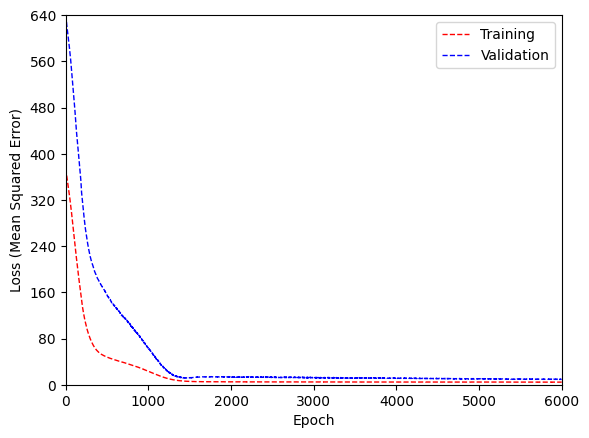

In [ ]:
plt.plot(history.history["loss"], "r--", color="red", linewidth=1)
plt.plot(history.history["val_loss"], "r--", color="blue", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend(["Training", "Validation"], loc="upper right")
plt.grid(False)
if np.max(history.history["loss"]) > np.max(history.history["val_loss"]):
  max = np.max(history.history["loss"])
else:
  max = np.max(history.history["val_loss"])
def roundBy(max, base=10):
    return int(base * round(float(max)/base))
max = roundBy(max)
plt.ylim(0,max)
plt.xlim(0,epochs)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.


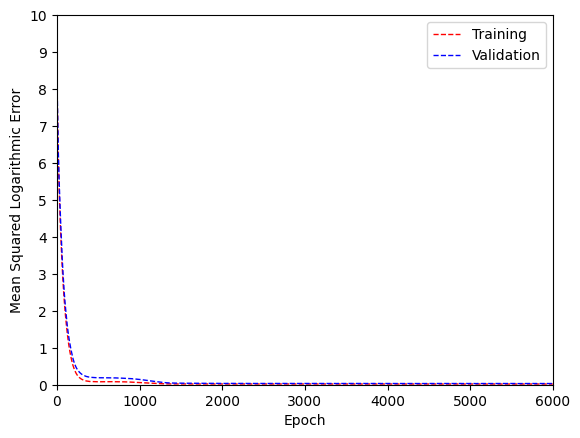

In [ ]:
plt.plot(history.history["msle"], "r--", color="red", linewidth=1)
plt.plot(history.history["val_msle"], "r--", color="blue", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Logarithmic Error")
plt.legend(["Training", "Validation"], loc="upper right")
plt.grid(False)
if np.max(history.history["msle"]) > np.max(history.history["val_msle"]):
  max = np.max(history.history["msle"])
else:
  max = np.max(history.history["val_msle"])
def roundBy(max, base=10):
    return int(base * round(float(max)/base))
max = roundBy(max)
plt.ylim(0,max)
plt.xlim(0,epochs)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

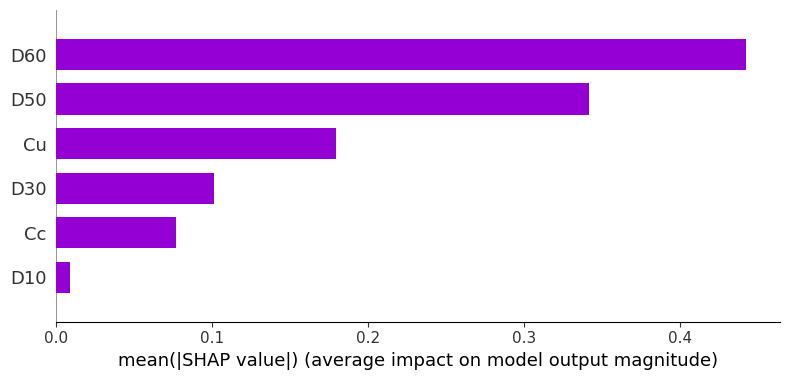

In [ ]:
explainer = shap.DeepExplainer(model, input_train)
shap_values = explainer.shap_values(input_validation)
shap.summary_plot(shap_values[0], plot_type = "bar", feature_names=["D10", "D30", "D50", "D60", "Cu", "Cc"], color="darkviolet")

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[0].numpy(), shap_values[0][0], features=["D10", "D30", "D50", "D60", "Cu", "Cc"])

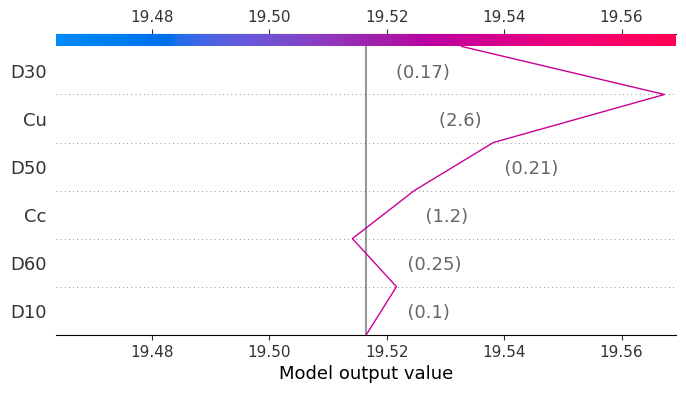

In [ ]:
shap.decision_plot(explainer.expected_value[0].numpy(), shap_values[0][0], features=input_train[0,:], feature_names=["D10", "D30", "D50", "D60", "Cu", "Cc"])

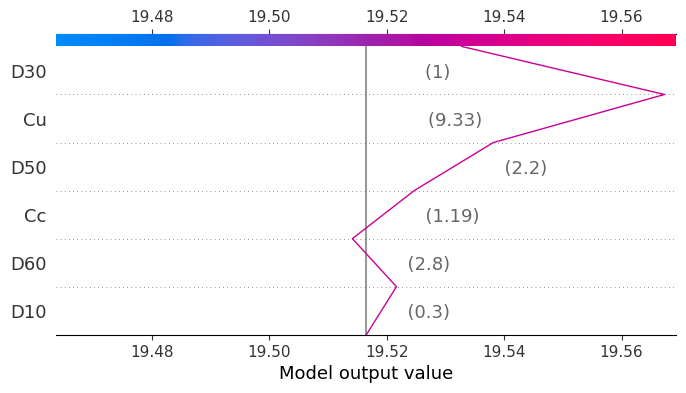

In [ ]:
shap.decision_plot(explainer.expected_value[0].numpy(), shap_values[0][0], features=input_validation[0,:], feature_names=["D10", "D30", "D50", "D60", "Cu", "Cc"])

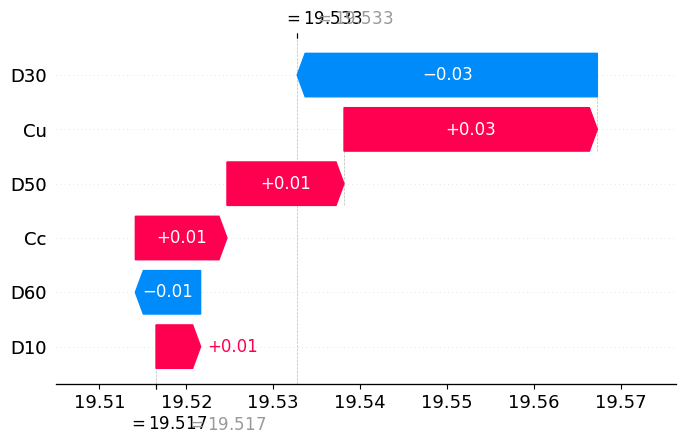

In [ ]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[0].numpy(), shap_values[0][0], feature_names=["D10", "D30", "D50", "D60", "Cu", "Cc"])

In [ ]:
#Case_Study
D10, D30, D50, D60 = 0.171, 0.462, 1.081, 1.445
Cu = D60/D10
Cc = (D30*D30)/(D10*D60)
results_size = np.zeros((1, 3))
results = np.zeros_like(results_size, dtype=float)
results[0, :] = model.predict(np.array([[D10, D30, D50, D60, Cu, Cc]]))
results = results[0]
print("The maximum dry unit weight is " + str(round(results[0],3)) + " kN/m3")
print("The optimum moisture content is " + str(round(results[1],3)) + " %")
print("The California bearing ratio is " + str(round(results[2],3)) + " %")

1/1 [==============================] - 0s 58ms/step
The maximum dry unit weight is 19.598 kN/m3
The optimum moisture content is 11.046 %
The California bearing ratio is 21.419 %
